## 正則化項

### Ridge

In [105]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error

In [70]:
df = pd.read_csv("../data/Hitters.csv")

In [71]:
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [72]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [73]:
# 欠損値対応
df.dropna(inplace=True)
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,403.642586,107.828897,11.619772,54.745247,51.486692,41.114068,7.311787,2657.543726,722.186312,69.239544,361.220532,330.418251,260.266160,290.711027,118.760456,8.593156,535.925882
std,147.307209,45.125326,8.757108,25.539816,25.882714,21.718056,4.793616,2286.582929,648.199644,82.197581,331.198571,323.367668,264.055868,279.934575,145.080577,6.606574,451.118681
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,67.500000
25%,282.500000,71.500000,5.000000,33.500000,30.000000,23.000000,4.000000,842.500000,212.000000,15.000000,105.500000,95.000000,71.000000,113.500000,8.000000,3.000000,190.000000
50%,413.000000,103.000000,9.000000,52.000000,47.000000,37.000000,6.000000,1931.000000,516.000000,40.000000,250.000000,230.000000,174.000000,224.000000,45.000000,7.000000,425.000000
75%,526.000000,141.500000,18.000000,73.000000,71.000000,57.000000,10.000000,3890.500000,1054.000000,92.500000,497.500000,424.500000,328.500000,322.500000,192.000000,13.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1377.000000,492.000000,32.000000,2460.000000


In [74]:
# データの準備
y_col = 'Salary'
X = df.loc[:, df.columns!=y_col]
X

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,A


In [75]:
y = df[y_col]

In [76]:
# 標準化のために数値カラムのリストを作成
numeric_cols = X.select_dtypes(include=np.number).columns.to_list()

In [77]:
X.dtypes

AtBat        int64
Hits         int64
HmRun        int64
Runs         int64
RBI          int64
Walks        int64
Years        int64
CAtBat       int64
CHits        int64
CHmRun       int64
CRuns        int64
CRBI         int64
CWalks       int64
League         str
Division       str
PutOuts      int64
Assists      int64
Errors       int64
NewLeague      str
dtype: object

In [78]:
X

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,A


In [79]:
# ダミー変数 （数値カラム作成の後)
X = pd.get_dummies(X, drop_first=True)
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,False,True,False


In [ ]:
# hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 標準化
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [82]:
X_train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
275,0.374183,0.079339,0.759350,-0.036632,0.127298,-0.296460,-1.139596,-0.906175,-0.919988,-0.550834,-0.911932,-0.815974,-0.833650,-0.629885,0.644269,0.260164,False,True,False
134,-1.795062,-1.530461,-0.745509,-1.472432,-0.853766,-1.260217,0.390956,-0.925691,-0.935379,-0.663465,-0.898341,-0.740174,-0.783531,-0.535854,-0.769140,-1.203755,True,True,True
19,-1.904206,-1.684826,-0.398234,-1.552199,-1.180788,-1.308404,0.172306,-0.883803,-0.885785,-0.550834,-0.942512,-0.791856,-0.804414,-0.312965,-0.722249,-1.057363,True,True,True
140,1.322375,0.785006,2.495725,1.199751,2.702594,1.149175,-1.139596,-0.898559,-0.897756,-0.353731,-0.826988,-0.626474,-0.750119,0.094505,-0.842825,0.699339,False,True,False
99,0.121786,0.035235,0.412075,0.601501,-0.158845,-0.248272,-0.046344,-0.215961,-0.263296,-0.353731,-0.031910,-0.474874,0.039246,0.000473,-0.829427,-0.910971,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,1.322375,0.674745,-1.324301,1.558701,-0.894644,0.908236,-1.139596,-0.641514,-0.665178,-0.874647,-0.487211,-0.836647,-0.578881,0.028334,-0.789236,-0.032620,True,False,True
240,-0.921907,-0.692483,-0.745509,-0.794415,-0.894644,-0.392836,1.046907,1.118294,1.128755,-0.212942,0.970433,0.424390,0.644843,-0.800534,-0.266743,-0.910971,False,True,False
151,-1.740490,-1.486357,-0.861267,-1.153365,-1.221666,-1.067465,-1.139596,-1.092771,-1.077320,-0.762017,-1.017263,-0.940010,-0.892121,-0.918944,-0.494496,-1.057363,False,True,False
62,-1.160660,-1.155576,-1.324301,-1.113482,-1.466932,-1.452968,-0.702295,-0.699111,-0.731873,-0.874647,-0.776021,-0.853874,-0.800237,-0.581128,0.463406,0.552947,False,True,False


In [83]:
X_train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
count,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,1.840000e+02,184.000000
mean,-1.882552e-16,-1.351576e-16,9.654113e-18,9.412760e-17,2.413528e-17,8.326673e-17,-9.171408e-17,-4.827057e-17,2.896234e-17,9.654113e-18,9.171408e-17,-2.413528e-17,-2.413528e-17,-2.413528e-17,8.688702e-17,0.000000
std,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729e+00,1.002729
min,-2.634109e+00,-2.368440e+00,-1.324301e+00,-2.190332e+00,-2.080097e+00,-1.983034e+00,-1.358246e+00,-1.210345e+00,-1.178218e+00,-8.887262e-01,-1.149776e+00,-1.050265e+00,-1.021594e+00,-1.016458e+00,-8.696190e-01,-1.350147
25%,-8.400484e-01,-7.641520e-01,-7.455091e-01,-7.944153e-01,-8.128886e-01,-7.301504e-01,-7.022951e-01,-7.907427e-01,-8.045538e-01,-6.669846e-01,-8.108485e-01,-7.513715e-01,-7.146184e-01,-6.168251e-01,-8.160301e-01,-0.764579
50%,5.698197e-02,-3.092083e-02,-2.824756e-01,-1.363403e-01,-1.588454e-01,-2.000843e-01,-2.649946e-01,-3.130670e-01,-3.308462e-01,-3.537306e-01,-3.326122e-01,-2.491963e-01,-3.220243e-01,-2.798795e-01,-4.911471e-01,-0.252208
75%,8.022335e-01,7.243624e-01,5.278330e-01,6.513555e-01,7.200251e-01,6.191089e-01,6.096064e-01,5.188791e-01,4.793306e-01,2.974153e-01,3.707264e-01,3.072448e-01,2.574696e-01,8.928055e-02,6.074264e-01,0.699339
max,1.915847e+00,2.857900e+00,3.306034e+00,2.994501e+00,2.702594e+00,3.076688e+00,2.796109e+00,2.939508e+00,3.223671e+00,4.517545e+00,2.822218e+00,3.570091e+00,4.725316e+00,3.779140e+00,2.426101e+00,3.334393


In [84]:
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [85]:
X_test.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,-0.056868,-0.042086,0.069195,-0.023001,0.081764,-0.006113,0.072668,0.117035,0.137915,0.286589,0.190365,0.213258,0.162163,-0.013369,-0.246648,-0.306873
std,1.015103,0.982829,1.043711,1.061051,1.181688,1.148889,1.152103,1.269122,1.324776,1.442645,1.367149,1.333562,1.306809,0.912933,0.877710,0.846288
min,-2.640931,-2.302284,-1.324301,-2.110565,-1.957464,-1.934846,-1.358246,-1.220818,-1.186769,-0.888726,-1.163367,-1.064047,-1.034123,-1.016458,-0.869619,-1.350147
25%,-0.863924,-0.846847,-0.861267,-0.934007,-0.874205,-0.971090,-0.920945,-0.908793,-0.878090,-0.712741,-0.816795,-0.724669,-0.766825,-0.622920,-0.822729,-0.910971
50%,-0.035109,-0.163233,-0.282476,-0.076515,-0.199723,-0.248272,-0.264995,-0.294027,-0.268426,-0.283336,-0.266356,-0.309492,-0.290700,-0.177142,-0.722249,-0.471795
75%,0.824403,0.773980,0.932987,0.880685,1.047047,1.004612,1.046907,0.819598,0.805539,0.899285,0.797147,0.670740,0.711668,0.138038,0.111729,-0.032620
max,1.752131,2.019921,2.495725,2.117068,2.866104,2.691186,3.670710,5.459503,6.084728,6.826473,6.186011,4.641628,5.502151,3.239330,2.359115,2.309650


In [96]:
# モデル学習　
ridge = Ridge()
ridge.fit(X_train, y_train)
# 予測
y_pred = ridge.predict(X_test)

In [97]:
y_pred

array([ 513.86364069, 1039.78316991,   47.68216176,  580.94220773,
        569.5598426 ,  350.40223621, 1094.79710479,  433.15718067,
       1512.82453879,  835.9120895 ,  529.10609321,  733.85867062,
        410.1404281 ,  667.75129634,  114.98578228,  456.20780504,
        260.32440943,  797.6079581 ,  954.14199904,  261.90899622,
        201.57047425,  365.58786246,  567.86747547,   79.55225117,
        181.12538425,  385.92438271,  722.69151967,  310.2559701 ,
        192.06254157,  554.77237418,  399.18242435,  736.35534388,
        177.08341553,  233.55861173,  550.65241188,  449.55124911,
        579.76821364,  484.44729327, 1442.76040594,  352.5847412 ,
       1264.08333398,  249.50171218,  151.08498754,  333.93158719,
        701.70401843, 1067.54970839,  376.85763797,  576.93783273,
        927.75488323, 1389.37953291,  413.52430318,  721.9797592 ,
        107.19176591,  204.69197885, 1002.57216563, 1197.57391487,
        413.20662555, 1720.56565173,  191.90846069,  709.49434

In [98]:
y_test

166     640.0
249     487.5
294     185.0
9      1100.0
190     202.5
        ...  
45      305.0
119     362.5
139     100.0
291     425.0
312     550.0
Name: Salary, Length: 79, dtype: float64

In [99]:
mse = mean_squared_error(y_test, y_pred)

In [100]:
mse

118513.26135456562

In [101]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

251.01058042384867

In [104]:
ridge.coef_

array([-255.99352472,  265.41620796,   49.85450911,  -43.4415344 ,
          6.40827279,  126.64463957,  -39.99788141, -180.02267219,
        242.39467113,  -36.09606293,  281.13852012,   46.31799934,
       -164.64027314,   70.88806172,   41.295514  ,  -34.06922615,
         -8.54724705,  -97.91075067,   35.72441367])

In [103]:
X.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'League_N', 'Division_W', 'NewLeague_N'],
      dtype='str')

In [106]:
# 線形回帰との比較
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.coef_

array([-269.10981701,  272.90887884,   59.97669544,  -55.37512444,
          3.61504229,  131.08295524,  -14.78202567, -514.20110584,
        550.22369897,  -12.29554582,  299.04286135,    4.60615938,
       -156.78117836,   73.32237801,   54.94973217,  -35.64306984,
          1.59251626,  -95.02251105,   28.46798552])

## 様々なλ

In [108]:
df = pd.read_csv("../data/Hitters.csv")
# 欠損値対応
df.dropna(inplace=True)
# データの準備
y_col = 'Salary'
X = df.loc[:, df.columns!=y_col]
y = df[y_col]
# 標準化のために数値カラムのリストを作成
numeric_cols = X.select_dtypes(include=np.number).columns.to_list()
# ダミー変数 （数値カラム作成の後)
X = pd.get_dummies(X, drop_first=True)
# hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
# 標準化
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [113]:
alphas = np.logspace(-3, 3) 
mse_list = []
coefs = []
for alpha in alphas:
    model = Ridge(alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    coefs.append(model.coef_)

In [110]:
alphas

array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
       2.81176870e-01, 3.72759372e-01, 4.94171336e-01, 6.55128557e-01,
       8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03])

In [111]:
1e-4

0.0001

In [112]:
1e+4

10000.0

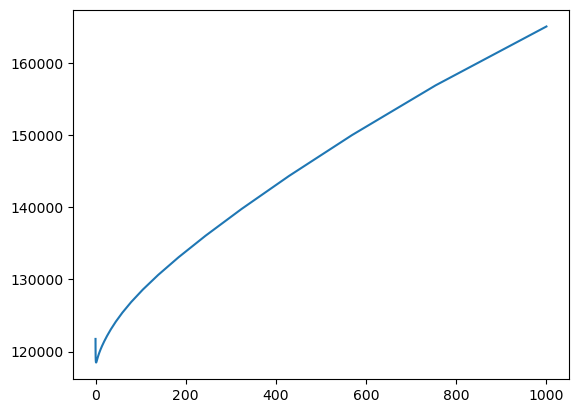

In [117]:
# λ vs MSE
import matplotlib.pyplot as plt
plt.plot(alphas, mse_list)

Text(0, 0.5, 'test MSE')

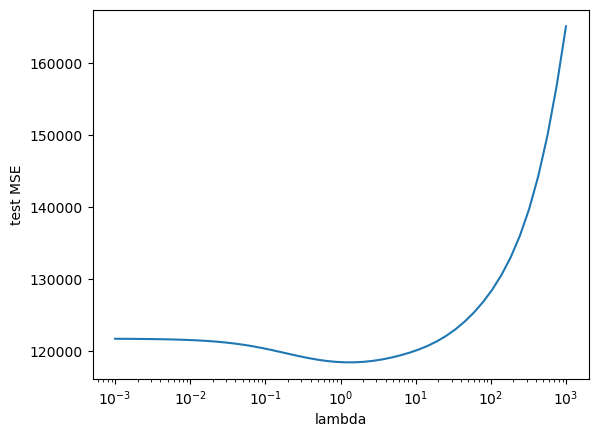

In [121]:
plt.plot(alphas, mse_list)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('test MSE')

Text(0, 0.5, 'standardized coefficients')

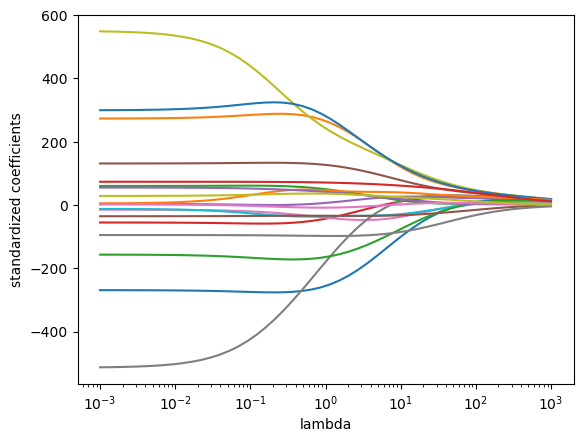

In [122]:
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('standardized coefficients')